<a href="https://colab.research.google.com/github/aditya30103/ELL881-Project/blob/main/counterspeech_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!nvidia-smi

Wed Oct 23 18:54:43 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla T4                       Off | 00000000:00:04.0 Off |                    0 |
| N/A   60C    P8              10W /  70W |      0MiB / 15360MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [2]:
!pip install transformers
!pip install transformer_lens
!pip install tqdm

In [3]:
import torch
from transformers import (
    GPT2Tokenizer,
    GPT2LMHeadModel,
    AdamW,
    get_linear_schedule_with_warmup,
)
from torch.utils.data import DataLoader, Dataset
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from torch.cuda.amp import GradScaler, autocast
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
import shutil  # For zipping the model directory

In [4]:
df = pd.read_csv('CONAN_clean.csv')

In [5]:
model_name = 'gpt2-medium'

In [6]:
# Load the tokenizer
tokenizer = GPT2Tokenizer.from_pretrained(model_name)

# Add special tokens
special_tokens_dict = {
    'additional_special_tokens': ['<|startoftext|>', '<|endoftext|>', '<|sep|>', '<|pad|>']
}
num_added_toks = tokenizer.add_special_tokens(special_tokens_dict)

# Set pad token to the new <|pad|> token
tokenizer.pad_token = '<|pad|>'

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:90: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [7]:
# Load the pre-trained model
model = GPT2LMHeadModel.from_pretrained(model_name)
model.resize_token_embeddings(len(tokenizer))

# Update model configuration
model.config.pad_token_id = tokenizer.pad_token_id
model.config.use_cache = False  # Necessary for gradient checkpointing

# Enable gradient checkpointing
model.gradient_checkpointing_enable()

# Move the model to the selected device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

Using device: cuda


In [8]:
class CONANDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=512):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        hate_speech = self.df.loc[idx, 'hateSpeech']
        counterspeech = self.df.loc[idx, 'counterSpeech']
        input_text = f"<|startoftext|>{hate_speech}<|sep|>{counterspeech}<|endoftext|>"

        encoding = self.tokenizer(
            input_text,
            truncation=True,
            max_length=self.max_length,
            padding='max_length',
            return_tensors='pt',
            add_special_tokens=False,
        )
        input_ids = encoding['input_ids'].squeeze()
        attention_mask = encoding['attention_mask'].squeeze()

        # Find the index of the separator token
        sep_token_id = self.tokenizer.convert_tokens_to_ids('<|sep|>')
        sep_indices = (input_ids == sep_token_id).nonzero(as_tuple=True)[0]
        sep_index = sep_indices[0] if len(sep_indices) > 0 else 0

        # Create labels and mask the hate speech tokens
        labels = input_ids.clone()
        labels[:sep_index + 1] = -100  # Mask hate speech and separator

        return {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'labels': labels
        }

In [9]:
# Split the DataFrame into train and validation sets
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

In [10]:
# Instantiate the dataset
train_dataset = CONANDataset(train_df, tokenizer)
val_dataset = CONANDataset(val_df, tokenizer)

In [11]:
def collate_fn(batch):
    input_ids = torch.stack([item['input_ids'] for item in batch])
    attention_mask = torch.stack([item['attention_mask'] for item in batch])
    labels = torch.stack([item['labels'] for item in batch])

    return {
        'input_ids': input_ids,
        'attention_mask': attention_mask,
        'labels': labels
    }

In [12]:
# Due to memory constraints, set batch_size to 1 and use gradient accumulation
train_batch_size = 1
gradient_accumulation_steps = 8  # Adjust based on available memory

train_dataloader = DataLoader(train_dataset, batch_size=train_batch_size, shuffle=True, collate_fn=collate_fn)
val_dataloader = DataLoader(val_dataset, batch_size=1, shuffle=False, collate_fn=collate_fn)

In [13]:
optimizer = AdamW(model.parameters(), lr=5e-5)

/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


In [14]:
num_epochs = 3  # Adjust the number of epochs as needed
total_steps = (len(train_dataloader) // gradient_accumulation_steps) * num_epochs
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=0, num_training_steps=total_steps
)

In [15]:
scaler = GradScaler()

<ipython-input-15-9f6a838c5572>:1: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [16]:
# Lists to store losses
train_losses = []
val_losses = []

# Training loop with gradient accumulation and mixed precision
for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0
    optimizer.zero_grad()
    progress_bar = tqdm(enumerate(train_dataloader), total=len(train_dataloader), desc=f"Epoch {epoch + 1}")

    for step, batch in progress_bar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        with autocast():  # Enable mixed precision
            outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            loss = loss / gradient_accumulation_steps  # Normalize loss

        scaler.scale(loss).backward()

        if (step + 1) % gradient_accumulation_steps == 0 or (step + 1) == len(train_dataloader):
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
            scheduler.step()

        total_loss += loss.item() * gradient_accumulation_steps  # Multiply back to get actual loss

        # Update the progress bar
        progress_bar.set_postfix({'loss': loss.item() * gradient_accumulation_steps})

    avg_loss = total_loss / len(train_dataloader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch + 1}/{num_epochs}, Training Loss: {avg_loss:.4f}")

    # Validation step
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for val_batch in val_dataloader:
            val_input_ids = val_batch['input_ids'].to(device)
            val_attention_mask = val_batch['attention_mask'].to(device)
            val_labels = val_batch['labels'].to(device)

            with autocast():
                val_outputs = model(val_input_ids, attention_mask=val_attention_mask, labels=val_labels)
                loss = val_outputs.loss

            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_dataloader)
    val_losses.append(avg_val_loss)
    print(f"Epoch {epoch + 1}/{num_epochs}, Validation Loss: {avg_val_loss:.4f}")
    model.train()  # Set back to training mode

Epoch 1:   0%|          | 0/11990 [00:00<?, ?it/s]<ipython-input-16-c8d387ad63c6>:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():  # Enable mixed precision
Epoch 1: 100%|██████████| 11990/11990 [46:53<00:00,  4.26it/s, loss=0.0547]
<ipython-input-16-c8d387ad63c6>:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1/3, Training Loss: 0.6338
Epoch 1/3, Validation Loss: 0.2027


Epoch 2: 100%|██████████| 11990/11990 [46:36<00:00,  4.29it/s, loss=0.0544]


Epoch 2/3, Training Loss: 0.2015
Epoch 2/3, Validation Loss: 0.1879


Epoch 3: 100%|██████████| 11990/11990 [46:36<00:00,  4.29it/s, loss=0.224]


Epoch 3/3, Training Loss: 0.1870
Epoch 3/3, Validation Loss: 0.1822


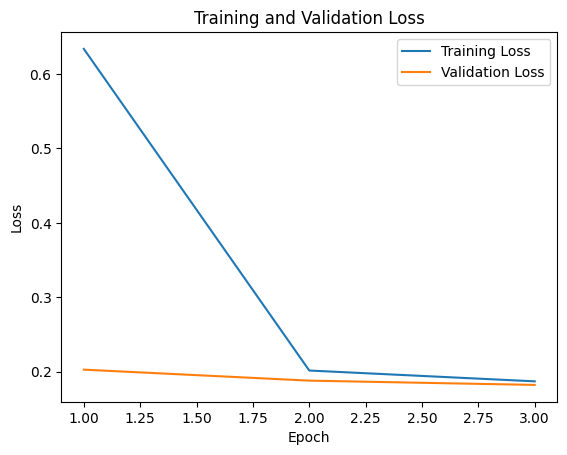

In [17]:
# Plot the training and validation loss
plt.figure()
plt.plot(range(1, num_epochs + 1), train_losses, label="Training Loss")
plt.plot(range(1, num_epochs + 1), val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.savefig("training_validation_loss.png")
plt.show()

In [18]:
# Save the finetuned model and tokenizer
model_save_path = 'finetuned_gpt2_medium'
model.save_pretrained(model_save_path)
tokenizer.save_pretrained(model_save_path)

('finetuned_gpt2_medium/tokenizer_config.json',
 'finetuned_gpt2_medium/special_tokens_map.json',
 'finetuned_gpt2_medium/vocab.json',
 'finetuned_gpt2_medium/merges.txt',
 'finetuned_gpt2_medium/added_tokens.json')

In [19]:
import shutil

# Zip the model directory
shutil.make_archive('finetuned_gpt2_medium', 'zip', model_save_path)

'/content/finetuned_gpt2_medium.zip'

In [ ]:
from google.colab import files

# Download the zipped model
files.download('finetuned_gpt2_medium.zip')

In [21]:
def generate_counterspeech(hate_speech, max_length=100):
    model.eval()
    input_text = f"<|startoftext|>{hate_speech}<|sep|>"

    # Tokenize the input text with attention mask
    inputs = tokenizer(
        input_text,
        return_tensors='pt',
        add_special_tokens=False,
    )
    input_ids = inputs['input_ids'].to(device)
    attention_mask = inputs['attention_mask'].to(device)

    with torch.no_grad():
        generated_ids = model.generate(
            input_ids,
            attention_mask=attention_mask,
            max_length=input_ids.size(1) + max_length,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.convert_tokens_to_ids('<|endoftext|>'),
            do_sample=True,
            top_k=50,
            top_p=0.95,
            temperature=0.7,
            repetition_penalty=1.2,
        )

    generated_text = tokenizer.decode(generated_ids[0], skip_special_tokens=True)
    # Extract the counterspeech part
    if '<|sep|>' in generated_text:
        counterspeech = generated_text.split('<|sep|>')[-1].split('<|endoftext|>')[0].strip()
    else:
        counterspeech = generated_text.strip()
    return counterspeech

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Counterspeech: Immigrants are taking our jobs.The only thing that is going to be a source of employment for immigrants would come from them directly, not hiring people through 'university' recruitment agencies and/or employers who make the decisions based on their personal beliefs (which I do understand).


In [ ]:
hate_speech_example = "Immigrants are taking our jobs."
print("Counterspeech:", generate_counterspeech(hate_speech_example))

In [ ]:
print("Special tokens:", tokenizer.special_tokens_map)